### Zyxin segmentation and object feature analysis

with Patrick's 2D fixed image two types of Zyxin

Liya Ding, 2025.4

In [1]:
import os
import sys
import tifffile 
import czifile
import numpy as np

In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.FA_object_segmentation import FA_obj_segmenter
from core.FA_obj_feature_extraction import FA_obj_feature_extractor
from utils.display_utils import display_fa_segmentation_panels

In [3]:
image_2D_4CH_dir =  '/mnt/d/lding/FA/data/250406_Complete_Phalloidin405_ZyxinGFP_Zyxin647/rgb_ctrl_seq'

output_dir = '/mnt/d/lding/FA/analysis_results/250406_Complete_Phalloidin405_ZyxinGFP_Zyxin647/ctrl_ch2_major'
os.makedirs(output_dir, exist_ok=True)

major_fa_ch = 2
cellmask_ch = 0
supplementary_fa_ch = [1,0]

method_ID = 'code_org_20250507'

csv_output_dir = os.path.join(output_dir, method_ID+'_csv')
plot_output_dir = os.path.join(output_dir, method_ID+'_plot')
seg_output_dir = os.path.join(output_dir, method_ID+'_seg')

pixel_size = 0.17
time_point = 0

os.makedirs(csv_output_dir, exist_ok=True)
os.makedirs(plot_output_dir, exist_ok=True)
os.makedirs(seg_output_dir, exist_ok=True)

sub_dirs = ['mask', 'seg', 'label', 'togglelabel', 'rgb']
for sub_dir in sub_dirs:
    os.makedirs(os.path.join(seg_output_dir, sub_dir), exist_ok=True)


### for each 3D stack run through MIP and 8th frame

In [4]:
# flag for some optinal parts
flag_plot = True
flag_plot_save = True
flag_seg_save = True
flag_csv_save = True
flag_panel_plot = True
flag_run_all  = True

In [5]:
# select the cells that are single/disconnected and complete
ctrl_one_cell_list = [0,1,2,3,4,5,6,7,8,9]

In [6]:
# for all tif files 
filenames = [x for x in os.listdir(image_2D_4CH_dir) if os.path.isfile(os.path.join(image_2D_4CH_dir, x)) and ('.tif' in x)]

# # if not in run all mode, only test with the first image of the first movie
# if not flag_run_all:
#     filenames = filenames[:2]

for filenameID in range(0,len(filenames)):
    
    filename = filenames[filenameID]

    number = int(filename[-7:-4])
    if number not in ctrl_one_cell_list:
        continue

    input_multich_img = np.squeeze(tifffile.imread(os.path.join(image_2D_4CH_dir,filename)))
    input_multich_img = np.transpose(input_multich_img, (2, 0, 1))


    # Initialize the segmenter
    segmenter = FA_obj_segmenter(cellmask_ch = cellmask_ch, major_fa_ch = major_fa_ch, thres_cellmask = 25,     intensity_scaling_param = (10, 40),
                                    response_threshold = 0.01, major_FA_res_thresholds = [0.5, 0.5, 0.5], min_object_size= 10)

    # Perform segmentation
    [major_FA_seg, new_cell_mask] = segmenter.apply_fa_obj_segmentation(input_multich_img)
   
    # Extract Object features
    extractor = FA_obj_feature_extractor(filename = filename,  pax_seg = major_FA_seg, input_multich_img = input_multich_img,
                                                        new_cell_mask = new_cell_mask, filenameID = filenameID,supplementary_fa_ch=supplementary_fa_ch)

    [fa_obj_features, local_orientation] = extractor.extract_features()
    

    fa_obj_features.to_csv(os.path.join((csv_output_dir), 'fa_obj_features_'+filename+'.csv'))

    tifffile.imsave(os.path.join(os.path.join(seg_output_dir, 'label'), 'FA_obj_label_'+filename+'.tif'), major_FA_seg.astype(np.uint16))       
    tifffile.imsave(os.path.join(os.path.join(seg_output_dir, 'mask'), 'cell_mask_'+filename+'.tif'),new_cell_mask.astype(np.uint8))   
    
    # Plot figures for debug and presentation
    pax_image_label_overlay = display_fa_segmentation_panels(input_image = (input_multich_img[major_fa_ch,:,:]), input_cell_mask = new_cell_mask, input_obj_seg = major_FA_seg, local_orientation = local_orientation,
                                   plot_output_dir = plot_output_dir, filename = filename, flag_plot_save = flag_plot_save, flag_run_all = flag_run_all)

    tifffile.imsave(os.path.join(os.path.join(seg_output_dir, 'rgb'), 'pax_segrgb_'+filename+'.jpg'),pax_image_label_overlay)                     
       

/mnt/d/lding/UbuntuGitCodes/focal_adhesion_clustering/utils/img_utils.py:107: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return a[index]


In [7]:
input_multich_img.shape

(3, 1200, 1200)

In [8]:
filename[-7:-4]

'167'

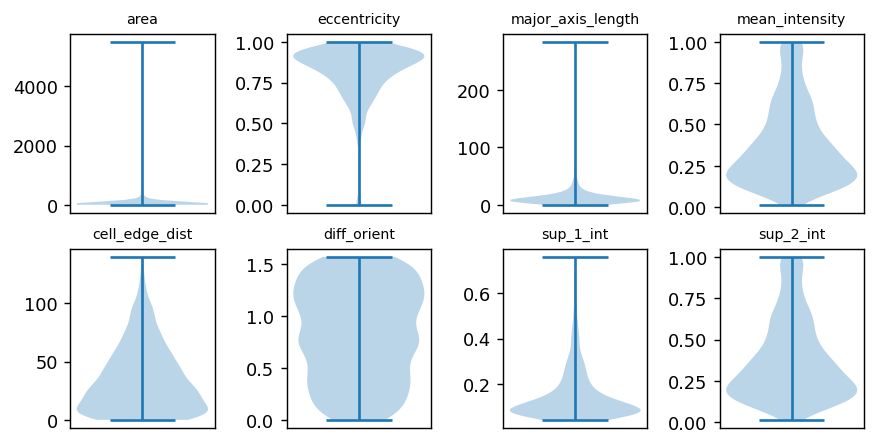

In [9]:
import matplotlib.pyplot as plt 
feature_list = ['area', 'eccentricity', 'major_axis_length','mean_intensity',
                                  'cell_edge_dist','diff_orient','sup_1_int','sup_2_int']

fig, ax = plt.subplots(2, 4, figsize=(8,4), dpi=128, facecolor='w', edgecolor='k')
# plt.subplots_adjust(left=0.3, right=0.7, top=0.8, bottom=0.2)
col_ind = 0
row_ind = 0
import seaborn as sns


for feature in feature_list:
    # sns.violinplot([prop_df_pfak_all[feature][::10].to_numpy().flat],split=True, inner="quart",color='lightblue',ax=ax[row_ind, col_ind])
    V = fa_obj_features[feature].to_numpy().flat
    ax[row_ind, col_ind].violinplot(V)
    ax[row_ind, col_ind].set_title(feature,fontsize=8)
    ax[row_ind, col_ind].set_xticks([],fontsize=8)
    # ax[row_ind, col_ind].set_yticks([np.percentile(V,0.0), int(np.percentile(V,0.0)*2+np.percentile(V,100.0)*1)/3, int(np.percentile(V,0.0)*1+np.percentile(V,100.0)*2)/3,np.percentile(V,100)],fontsize=5)
    # ax[row_ind, col_ind].set_ylim([np.percentile(V,0.0),np.percentile(V,100)])
    ax[row_ind, col_ind].tick_params(axis='both', which='minor', labelsize=8)    
    
    col_ind = col_ind + 1

    if(col_ind==4):
        col_ind = 0
        row_ind = 1
fig.subplots_adjust(wspace=0.5)

In [10]:
fa_obj_features

,filename,cell_ID,time_point,pixel_size,area,bbox_area,convex_area,eccentricity,equivalent_diameter,euler_number,...,min_intensity,minor_axis_length,orientation,perimeter,solidity,cell_edge_dist,cell_edge_orient,diff_orient,sup_1_int,sup_2_int
0,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,538.0,1672.0,1107.0,0.690114,26.172560,0.0,...,1.098039e-01,31.595444,-0.401777,235.202056,0.485998,15.0,0.000000,0.401777,0.058966,0.051418
1,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,19.0,30.0,20.0,0.611909,4.918491,1.0,...,5.098039e-02,4.639494,-1.480870,14.656854,0.950000,3.0,-0.463648,1.017222,0.083746,0.743225
2,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,25.0,40.0,30.0,0.880006,5.641896,1.0,...,1.686275e-01,4.238217,0.288014,19.656854,0.833333,5.0,-1.107149,1.395162,0.059470,0.087719
3,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,228.0,500.0,326.0,0.535714,17.038152,1.0,...,1.254902e-01,17.681710,-0.311458,78.562446,0.699387,10.0,0.000000,0.311458,0.062362,0.266039
4,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,12.0,16.0,13.0,0.646162,3.908820,1.0,...,8.627451e-02,3.371873,-0.559672,10.242641,0.923077,1.0,0.463648,1.023319,0.080864,0.774510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,30.0,40.0,32.0,0.909326,6.180387,1.0,...,3.921569e-11,4.092874,0.019559,21.313708,0.937500,18.0,-1.570796,1.551238,0.380202,0.318360
995,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,19.0,24.0,20.0,0.809715,4.918491,1.0,...,3.137255e-02,3.782172,-1.343339,14.242641,0.950000,10.0,1.570796,0.227457,0.102887,0.013856
996,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,98.0,225.0,131.0,0.944361,11.170384,1.0,...,4.313725e-02,7.099992,-0.883891,48.627417,0.748092,5.0,-2.677945,1.347539,0.115831,0.073065
997,Phalloidin405_ZyxinGFP_Zyxin647_ctrl_Composite...,9.0,0.0,0.07,26.0,48.0,32.0,0.904327,5.753627,1.0,...,1.176471e-02,3.935474,-0.454727,19.899495,0.812500,6.0,3.141593,0.454727,0.455568,0.171789
